# Data Understanding - Hospital Dataset (Regression)

This notebook covers the **Data Understanding** phase for the Hospital dataset. The target is `Duration (days)`, representing treatment length.

Key issues known: CSV headers repeated randomly in the rows. We handle this first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')

In [2]:
DATA_FILE = 'Hopsital Dataset.csv'

# Read as strings due to dirty data (repeated headers)
df_raw = pd.read_csv(DATA_FILE, dtype=str, low_memory=False)
print(f'Total raw dimensions: {df_raw.shape}')

Total raw dimensions: (833, 10)


## 1. Dirty Data Handling
We detect rows where a cell just contains the column name (meaning it's a repeated header row).

In [3]:
def get_junk_mask(df):
    mask = pd.Series(False, index=df.index)
    checks = [
        (df['Age'].astype(str).str.strip() == 'Age'),
        (df['Duration (days)'].astype(str).str.strip() == 'Duration (days)'),
        (df['Gender'].astype(str).str.strip() == 'Gender')
    ]
    for c in checks: mask = mask | c
    return mask

junk = get_junk_mask(df_raw)
print(f'Found {junk.sum()} junk rows (repeated headers). Removing them...')

df = df_raw.loc[~junk].copy()

Found 1 junk rows (repeated headers). Removing them...


Now we coerce our main numerical variables into actual float/int types.

In [4]:
df['Age_num'] = pd.to_numeric(df['Age'], errors='coerce')
df['Dosage_num'] = pd.to_numeric(df['Dosage (gram)'], errors='coerce')
df['Duration_num'] = pd.to_numeric(df['Duration (days)'], errors='coerce')

# Drop rows that failed to convert but originally had text
df_clean = df.dropna(subset=['Age_num', 'Dosage_num', 'Duration_num']).copy()
print(f'Clean rows with valid core numerics: {len(df_clean)}')
display(df_clean[['Age_num', 'Dosage_num', 'Duration_num']].describe())

Clean rows with valid core numerics: 831


,Age_num,Dosage_num,Duration_num
count,831.000000,831.000000,831.000000
mean,51.194946,5.048959,3.789410
std,18.587287,52.499935,3.009252
min,1.000000,0.020000,1.000000
25%,38.000000,0.500000,1.000000
50%,52.000000,1.000000,3.000000
75%,65.000000,1.000000,5.000000
max,90.000000,960.000000,28.000000


## 2. Univariate Analysis
Visualizing our cleaned target and dose variables.

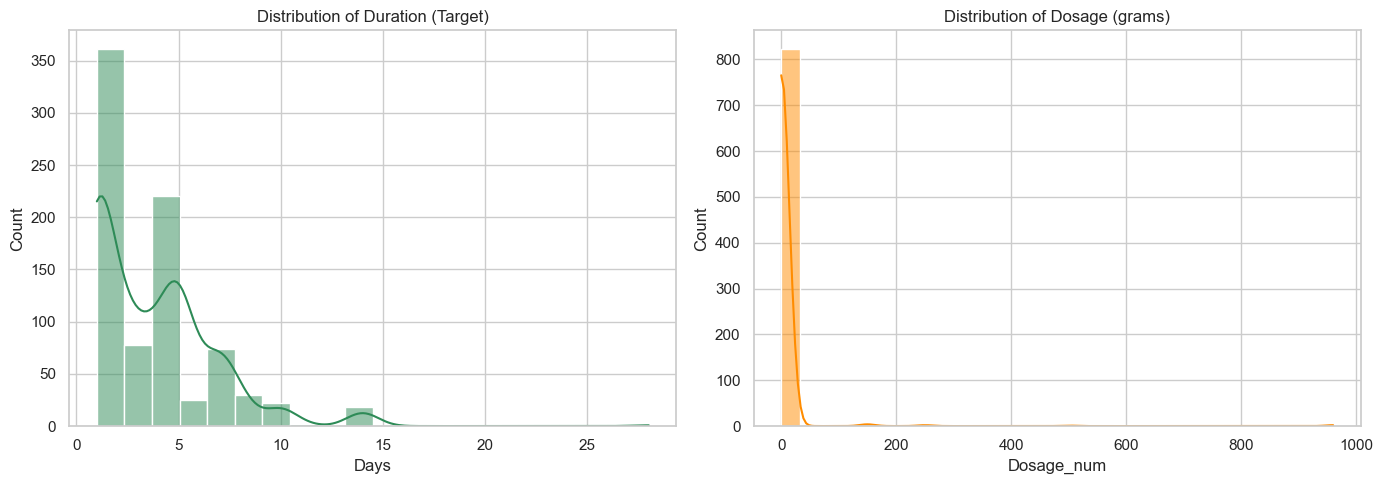

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['Duration_num'], bins=20, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Distribution of Duration (Target)')
axes[0].set_xlabel('Days')

sns.histplot(df_clean['Dosage_num'].dropna(), bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Dosage (grams)')

plt.tight_layout()
plt.show()

Visualizing Categoricals:

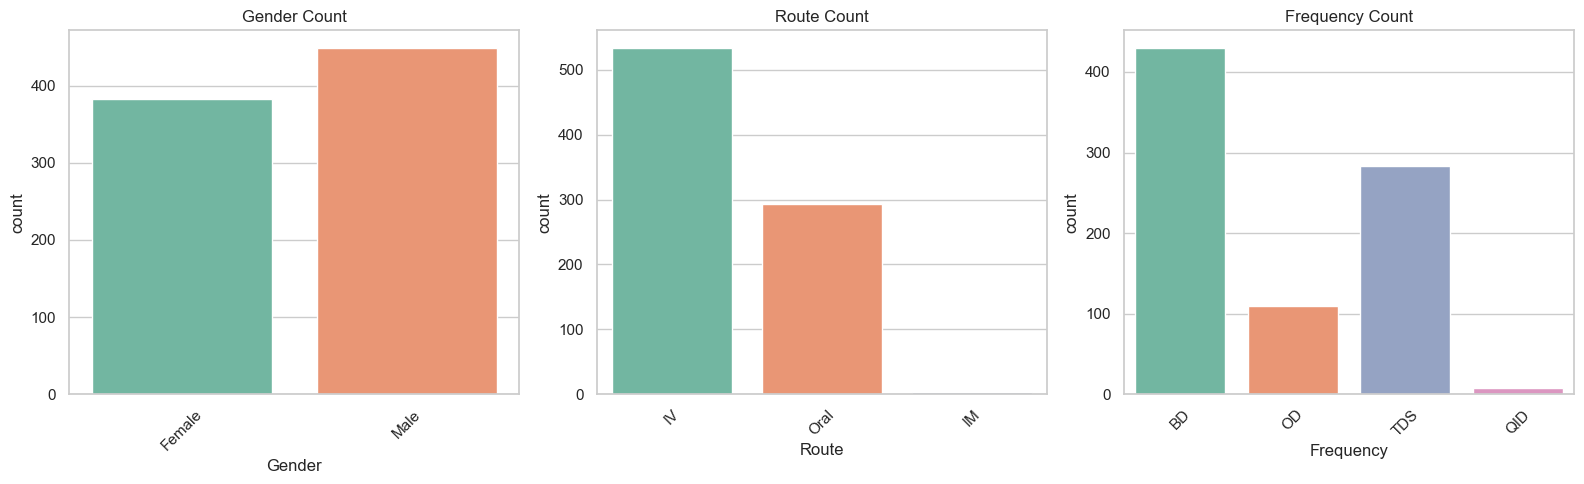

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_cols = ['Gender', 'Route', 'Frequency']

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_clean, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. High Cardinality Features
Let's check the number of unique values in our text columns.

In [7]:
card = df_clean[['Diagnosis', 'Name of Drug', 'Indication']].nunique()
display(card.to_frame('Unique Categories'))

,Unique Categories
Diagnosis,263
Name of Drug,55
Indication,220


## 4. Target-Feature Analysis & Top Categories
Let's visualize the top 10 most frequent Diagnoses, and see if the administration Route impacts the target Duration.

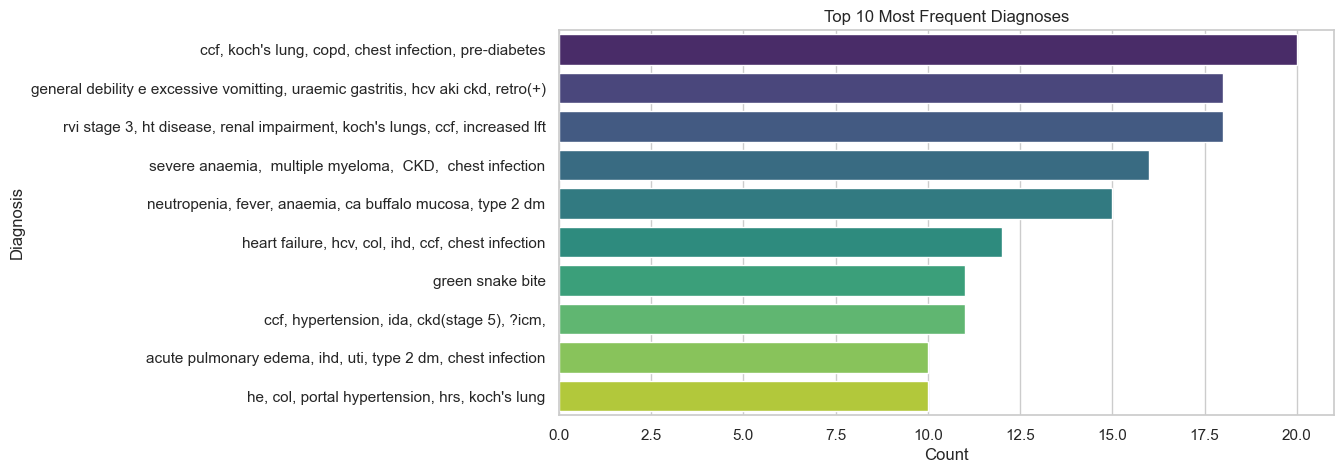

In [8]:
plt.figure(figsize=(10, 5))
top_diag = df_clean['Diagnosis'].value_counts().head(10)
sns.barplot(y=top_diag.index, x=top_diag.values, palette='viridis')
plt.title('Top 10 Most Frequent Diagnoses')
plt.xlabel('Count')
plt.show()

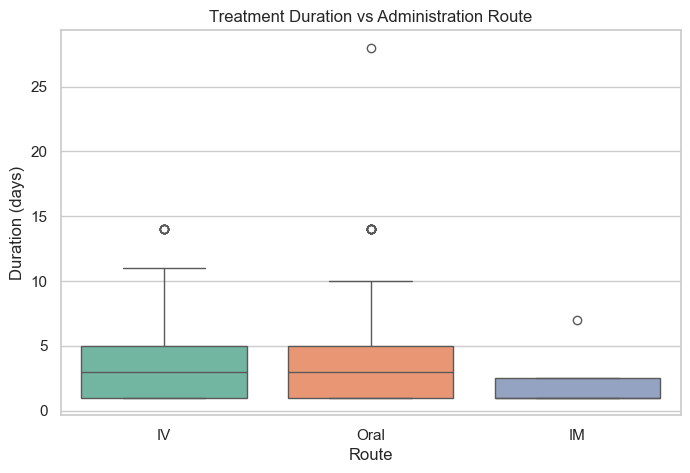

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Route', y='Duration_num', palette='Set2')
plt.title('Treatment Duration vs Administration Route')
plt.ylabel('Duration (days)')
plt.show()